# K-means Clustering 

En este ejercicio, implementará el algoritmo K-means y lo utilizará para la compresión de imágenes. 

* Empezarás con un conjunto de datos de muestra que te ayudará a intuir cómo funciona el algoritmo K-means. 
* Después, utilizarás el algoritmo K-means para la compresión de imágenes reduciendo el número de colores que aparecen en una imagen a sólo aquellos que son más comunes en esa imagen.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *

%matplotlib inline

<a name="1"></a>

## 1 - Implementación de K-means

El algoritmo K-means es un método para agrupar automáticamente puntos de datos
puntos de datos similares. 

* Concretamente, se da un conjunto de entrenamiento ${x^{(1)}, ..., x^{(m)}}$, y se desea
agrupar los datos en algunos "clusters" cohesivos. 


* K-means es un procedimiento iterativo que
     * Comienza adivinando los centroides iniciales, y luego 
     * Refina esta suposición mediante 
         * Asignando repetidamente los ejemplos a sus centros más cercanos, y luego 
         * Vuelve a calcular los centroides basándose en las asignaciones.

* En pseudocódigo, el algoritmo K-means es el siguiente:


    ``` python
    # Initialize centroids
    # K is the number of clusters
    centroids = kMeans_init_centroids(X, K)
    
    for iter in range(iterations):
        # Cluster assignment step: 
        # Assign each data point to the closest centroid. 
        # idx[i] corresponds to the index of the centroid 
        # assigned to example i
        idx = find_closest_centroids(X, centroids)

        # Move centroid step: 
        # Compute means based on centroid assignments
        centroids = compute_centroids(X, idx, K)
    ```
* El bucle interno del algoritmo realiza repetidamente dos pasos:
    1. Asignar cada ejemplo de entrenamiento $x^{(i)}$ a su centroide más cercano, y
    2. Recalcular la media de cada centroide utilizando los puntos asignados a él. 
    
    
* El algoritmo $K$-means siempre converge a un conjunto final de medias para los centroides. 

* Sin embargo, la solución convergente no siempre es ideal y depende de la configuración inicial de los centroides.
    * Por lo tanto, en la práctica el algoritmo K-means suele ejecutarse varias veces con diferentes inicializaciones aleatorias. 
    * Una forma de elegir entre estas diferentes soluciones de diferentes inicializaciones aleatorias es elegir la que tenga el menor valor de la función de coste (distorsión).

Se implementarán las dos fases del algoritmo K-means por separado
en las siguientes secciones. 
* Empezarás completando `encontrar_el_centroide_más_cercano` y luego procederás a completar `computar_centroides`.



<a name="1.1"></a>
### 1.1 Encontrar los centroides más cercanos

En la fase de "asignación de clusters" del algoritmo K-means, el
algoritmo asigna cada ejemplo de entrenamiento $x^{(i)}$ a su centroide
centroid, dadas las posiciones actuales de los centroides. 

<a name="ex01"></a>
* Esta función toma la matriz de datos `X` y las ubicaciones de todos los
centroids dentro de `centroids` 
* Debe dar salida a una matriz unidimensional `idx` (que tiene el mismo número de elementos que `X`) que contiene el índice del centroide más cercano (un valor en $\{1,...,K\}$, donde $K$ es el número total de centroides) a cada ejemplo de entrenamiento .
* En concreto, para cada ejemplo $x^{(i)}$ establecemos
$$c^{(i)} := j \quad \mathrm{que \; miniminiza} \quad ||x^{(i)} - \mu_j||^2,$$
donde 
* $c^{(i)}$ es el índice del centroide más cercano a $x^{(i)}$ (corresponde a `idx[i]` en el código de inicio), y 
* $\mu_j$ es la posición (valor) del centroide $j$. ( almacenado en `centroides` en el código de inicio)
 
Si te quedas atascado, puedes consultar las pistas presentadas después de la celda de abajo para ayudarte con la implementación.



In [2]:
def find_closest_centroids(X, centroids):
    """
    Calcula la membresía del centroide para cada ejemplo.
    Args:
        X (ndarray): (m, n) Valores de entrada
        centroids (ndarray): k centroides
    Returns:
        idx (array_like): (m,) centroides más cercanos
    """

    # Set K seleccionamos los K
    K = centroids.shape[0]


    idx = np.zeros(X.shape[0], dtype=int)

    # for ejemplo in range(X.shape[0]):
    #    distancia = []
    #    for centro in range(K):
    #        distancia_entre_ejemplo_y_cento = np.linalg.norm(X[ejemplo] - centroids[centro])
    #        distancia.append(distancia_entre_ejemplo_y_cento)
    #    idx[ejemplo] = np.argmin(distancia) 
    
    
    # codigo con lista por comprension
    for ej in range(X.shape[0]):
        idx[ej] = np.argmin( [np.linalg.norm(X[ej] - centroids[centro]) for centro in range(K) ]) 
    
 
    
    return idx

Ahora vamos a comprobar su implementación utilizando un conjunto de datos de ejemplo

In [3]:
# Load an example dataset that we will be using
# Cargar un conjunto de datos de ejemplo que vamos a utilizar
X = load_data()

El código siguiente imprime los cinco primeros elementos de la variable `X` y las dimensiones de la variable

In [4]:
print("Los primeros valores de  X son:\n", X[:5])
print('La forman de X es:', X.shape)

Los primeros valores de  X son:
 [[1.84207953 4.6075716 ]
 [5.65858312 4.79996405]
 [6.35257892 3.2908545 ]
 [2.90401653 4.61220411]
 [3.23197916 4.93989405]]
La forman de X es: (300, 2)


In [5]:
# Select an initial set of centroids (3 Centroids)
# Seleccionar un conjunto inicial de centroides (3 Centroides)
initial_centroids = np.array([[3,3], [6,2], [8,5]])

# Find closest centroids using initial_centroids
# Encontrar los centroides más cercanos utilizando initial_centroids
idx = find_closest_centroids(X, initial_centroids)

# Print closest centroids for the first three elements
# Imprime los centros más cercanos para los tres primeros elementos
print("First three elements in idx are:", idx[:3])


from public_tests import *

find_closest_centroids_test(find_closest_centroids)


First three elements in idx are: [0 2 1]
All tests passed!


**Expected Output**:
<table>
<tr>
<td> <b>First three elements in idx are<b></td>
<td> [0 2 1] </td> 
</tr>
</table>

<a name="1.2"></a>
### 1.2 Cálculo de las medias de los centroides

Dadas las asignaciones de cada punto a un centroide, la segunda fase del
algoritmo vuelve a calcular, para cada centroide, la media de los puntos que
que le fueron asignados.

### Ejercicio 2

Por favor, complete el `compute_centroids` a continuación para volver a calcular el valor de cada centroide

* Específicamente, para cada centroide $\mu_k$ establecemos
$$\mu_k = \frac{1}{|C_k|} \sum_{i \in C_k} x^{(i)}$$ 

    donde 
    * $C_k$ es el conjunto de ejemplos que se asignan al centroide $k$
    * $|C_k|$ es el número de ejemplos en el conjunto $C_k$

* Concretamente, si dos ejemplos digamos $x^{(3)}$ y $x^{(5)}$ se asignan al centroide $k=2$,
entonces debe actualizar $\mu_2 = \frac{1}{2}(x^{(3)}+x^{(5)})$.

Si te quedas atascado, puedes consultar las pistas presentadas después de la celda de abajo para ayudarte con la implementación.



In [6]:
def compute_centroids(X, idx, K):
    """
    Devuelve los nuevos centroides calculando las medias de los 
    puntos de datos asignados a cada centroide.
    
    Args:
        X (ndarray):   (m, n) Puntos de datos
        idx (ndarray): (m,) Matriz que contiene el índice del centroide más cercano para cada 
                       ejemplo en X. Concretamente, idx[i] contiene el índice del 
                       el centroide más cercano al ejemplo i
        K (int): número de centroides
    
    Devuelve:
        centroides (ndarray): (K, n) Nuevos centroides calculados
    """
    
    m, n = X.shape
    
    # Es necesario devolver correctamente las siguientes variables
    centroids = np.zeros((K, n))
    

    for centro in range(K):   
        points =  X [idx == centro]  
        centroids[centro] = np.mean(points, axis = 0)

    
    return centroids

Ahora comprueba tu implementación ejecutando la celda siguiente

In [7]:
K = 3
centroids = compute_centroids(X, idx, K)

print("The centroids are:", centroids)

# UNIT TEST
compute_centroids_test(compute_centroids)


The centroids are: [[2.42830111 3.15792418]
 [5.81350331 2.63365645]
 [7.11938687 3.6166844 ]]
All tests passed!


**Expected Output**:

2.42830111 3.15792418

5.81350331 2.63365645

7.11938687 3.6166844 

<a name="2"></a>

## 3 - K-means en un conjunto de datos de muestra 


Cuando se ejecuta el código de abajo, se producirá una
visualización que recorre el progreso del algoritmo en cada
cada iteración. 





In [8]:
def run_kMeans(X, initial_centroids, max_iters=10, plot_progress=True):
    """
    Ejecuta el algoritmo K-Means en la matriz de datos X, donde cada fila de X
    es un solo ejemplo
    """
    
    # Initialize values
    m, n               = X.shape 
    K                  = initial_centroids.shape[0]
    centroids          = initial_centroids
    previous_centroids = centroids    
    idx                = np.zeros(m)
    
    # Run K-Means
    for i in range(max_iters):
        
        #Output progress
        print("K-Means iteration {} / {}".format(i, max_iters-1))
        
        # For each example in X, assign it to the closest centroid
        idx = find_closest_centroids(X, centroids)
        
        # Optionally plot progress
        if plot_progress:
            plot_progress_kMeans(X, centroids, previous_centroids, idx, K, i)
            previous_centroids = centroids
            
        # Given the memberships, compute new centroids
        centroids = compute_centroids(X, idx, K)
    plt.show() 
    return centroids, idx

K-Means iteration 0 / 14
K-Means iteration 1 / 14
K-Means iteration 2 / 14
K-Means iteration 3 / 14
K-Means iteration 4 / 14
K-Means iteration 5 / 14
K-Means iteration 6 / 14
K-Means iteration 7 / 14
K-Means iteration 8 / 14
K-Means iteration 9 / 14
K-Means iteration 10 / 14
K-Means iteration 11 / 14
K-Means iteration 12 / 14
K-Means iteration 13 / 14
K-Means iteration 14 / 14


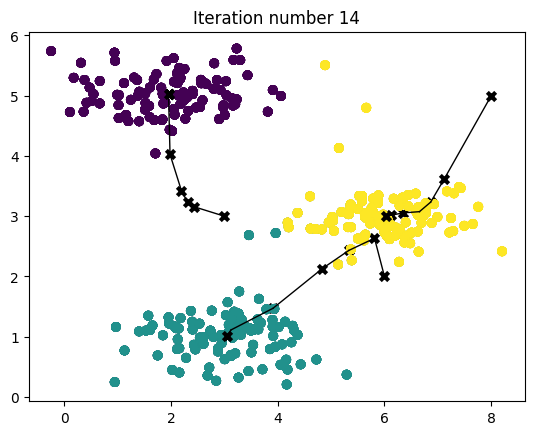

In [12]:
# Load an example dataset
X = load_data()

# Set initial centroids
initial_centroids = np.array([[3,3],[6,2],[8,5]])
K = 3

# Number of iterations
max_iters = 15

centroids, idx = run_kMeans(X, initial_centroids, max_iters, plot_progress=True)

<a name="3"></a>
## 3 - Inicialización aleatoria

La asignación inicial de los centroides para el conjunto de datos de ejemplo se diseñó de forma que se viera la misma figura que en la Figura 1. En la práctica, una buena estrategia para inicializar los centroides es seleccionar ejemplos aleatorios del
conjunto de entrenamiento.

En esta parte del ejercicio, debes entender cómo se implementa la función `kMeans_init_centroids`.
* El código primero baraja aleatoriamente los índices de los ejemplos (usando `np.random.permutation()`). 
* Luego, selecciona los primeros $K$ ejemplos basados en la permutación aleatoria de los índices. 
    * Esto permite que los ejemplos sean seleccionados al azar sin el riesgo de seleccionar el mismo ejemplo dos veces.

**Nota**: No necesitas implementar nada para esta parte del ejercicio.



In [13]:

def kMeans_init_centroids(X, K):
    """
    Esta función inicializa los K centroides que se van a 
    utilizar en K-Means en el conjunto de datos X
    
    Args:
        X (ndarray): Puntos de datos 
        K (int): número de centroides/clusters
    
    Devuelve:
        centroides (ndarray): Centroides inicializados
    """
    
    # Randomly reorder the indices of examples
    randidx = np.random.permutation(X.shape[0])
    
    # Take the first K examples as centroids
    centroids = X[randidx[:K]]
    
    return centroids

<a name="4"></a>
## 4 - 4 - Compresión de imágenes con K-means

En este ejercicio, se aplicará K-means a la compresión de imágenes. 

* En una representación directa de color de 24 bits de una imagen$^{2}$, cada píxel se representa como tres enteros sin signo de 8 bits (que van de 0 a 255) que especifican los valores de intensidad del rojo, el verde y el azul. Esta codificación suele denominarse codificación RGB.
* Nuestra imagen contiene miles de colores, y en esta parte del ejercicio, usted reducirá el número de
colores a 16 colores.
* Al hacer esta reducción, es posible representar (comprimir) la foto de una manera eficiente. 
* Específicamente, sólo necesita almacenar los valores RGB de los 16 colores seleccionados, y para cada píxel de la imagen ahora sólo necesita almacenar el índice del color en esa ubicación (donde sólo son necesarios 4 bits para representar 16 posibilidades).

En esta parte, utilizarás el algoritmo K-means para seleccionar los 16 colores que se utilizarán para representar la imagen comprimida.
* Concretamente, tratará cada píxel de la imagen original como un ejemplo de datos y utilizará el algoritmo K-means para encontrar los 16 colores que mejor agrupan (cluster) los píxeles en el espacio RGB tridimensional. 
* Una vez calculados los centros de los clusters en la imagen, se utilizarán los 16 colores para reemplazar los píxeles de la imagen original.



In [14]:
# Load an image of a bird
original_img = plt.imread('bird_small.png')



**Visualiza la imagen**

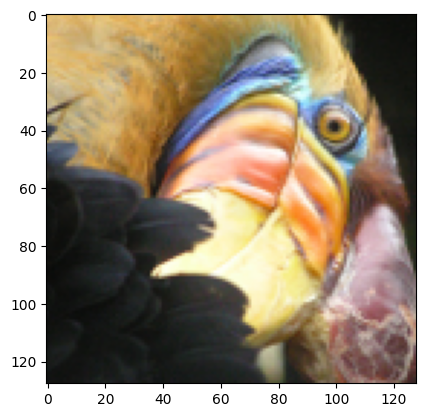

In [15]:
plt.imshow(original_img)

**Comprobar la dimensión de la variable**

Como siempre, imprimirás la forma de tu variable para familiarizarte con los datos.

In [16]:
print("la forma original es:", original_img.shape)

la forma original es: (128, 128, 3)


Como puedes ver, esto crea una matriz tridimensional `original_img` donde 
* los dos primeros índices identifican una posición de píxel, y
* el tercer índice representa el rojo, el verde o el azul. 

Por ejemplo, `original_img[50, 33, 2]` da la intensidad azul del píxel en la fila 50 y la columna 33.

#### Procesamiento de datos

Para llamar a `run_kMeans`, primero hay que transformar la matriz `original_img` en una matriz bidimensional.

* El código que se muestra a continuación reestructura la matriz `original_img` para crear una matriz de $m veces 3$ de colores de píxeles (donde
$m=16384 = 128\times128$)



In [17]:
# Divide by 255 so that all values are in the range 0 - 1
original_img = original_img / 255

# Reshape the image into an m x 3 matrix where m = number of pixels
# (in this case m = 128 x 128 = 16384)
# Each row will contain the Red, Green and Blue pixel values
# This gives us our dataset matrix X_img that we will use K-Means on.

# Rehacer la imagen en una matriz m x 3 donde m = número de píxeles
# (en este caso m = 128 x 128 = 16384)
# Cada fila contendrá los valores de los píxeles rojo, verde y azul
# Esto nos da nuestra matriz del conjunto de datos X_img en la que usaremos K-Means.

X_img = np.reshape(original_img, (original_img.shape[0] * original_img.shape[1], 3))

In [18]:
X_img.shape

(16384, 3)

<a name="4.2"></a>
### 4.2 K-Means on image pixels

Now, run the cell below to run K-Means on the pre-processed image.

K-Means iteration 0 / 19
K-Means iteration 1 / 19
K-Means iteration 2 / 19
K-Means iteration 3 / 19
K-Means iteration 4 / 19
K-Means iteration 5 / 19
K-Means iteration 6 / 19
K-Means iteration 7 / 19
K-Means iteration 8 / 19
K-Means iteration 9 / 19
K-Means iteration 10 / 19
K-Means iteration 11 / 19
K-Means iteration 12 / 19
K-Means iteration 13 / 19
K-Means iteration 14 / 19
K-Means iteration 15 / 19
K-Means iteration 16 / 19
K-Means iteration 17 / 19
K-Means iteration 18 / 19
K-Means iteration 19 / 19


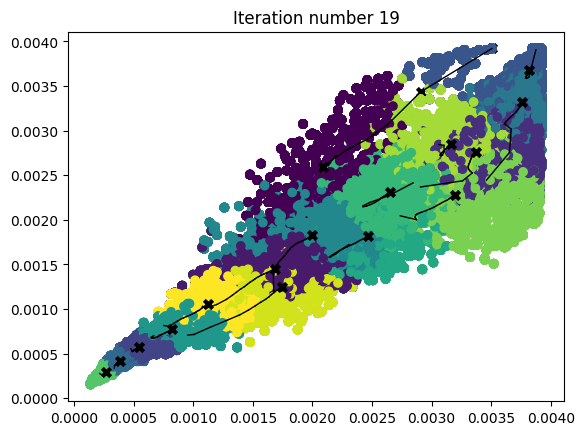

In [24]:
#  Ejecute su algoritmo K-Means en estos datos
# Deberías probar diferentes valores de K y max_iters aquí
K = 16                     
max_iters = 20              

# Usando la función que has implementado arriba. 
initial_centroids = kMeans_init_centroids(X_img, K) 

# Ejecutar K-Means - esto toma un par de minutos
centroids, idx = run_kMeans(X_img, initial_centroids, max_iters) 

In [25]:
print("Shape of idx:", idx.shape)
print("Closest centroid for the first five elements:\n", idx[:100])

Shape of idx: (16384,)
Closest centroid for the first five elements:
 [ 2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2
  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2 12
 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12
 10 12  2  2  2  2  2  2  2  2  2  2  2 12 12  2  2 12  2  2  2  6  2 12
  1 14  8  3]


<a name="4.3"></a>
### 4.3 Compress the image


In [26]:
centroids

array([[0.00209074, 0.00258908, 0.00324066],
       [0.00171069, 0.00146862, 0.00138989],
       [0.00337426, 0.00277047, 0.00175372],
       [0.00055087, 0.0005812 , 0.00054983],
       [0.00381814, 0.00368641, 0.00318043],
       [0.00038817, 0.00041856, 0.00037823],
       [0.0037639 , 0.00333064, 0.00241803],
       [0.00200524, 0.00183578, 0.00187988],
       [0.00083681, 0.00078111, 0.00073954],
       [0.00248153, 0.00182864, 0.00088542],
       [0.0026587 , 0.00231756, 0.00194143],
       [0.00026911, 0.00029276, 0.00025244],
       [0.00321529, 0.00228581, 0.00110267],
       [0.00316387, 0.00285664, 0.00279656],
       [0.00174953, 0.00124532, 0.00071753],
       [0.00113538, 0.00106824, 0.00110633]])

Después de encontrar los mejores $K=16$ colores para representar la imagen, ahora se puede
asignar cada posición de píxel a su centroide más cercano utilizando la función
función `find_closest_centroids`. 
* Esto le permite representar la imagen original utilizando las asignaciones de los centroides de cada píxel. 
* Observe que ha reducido significativamente el número de bits que se requieren para describir la imagen. 
    * La imagen original requería 24 bits para cada una de las ubicaciones de los píxeles de $128 \times128$, resultando en un tamaño total de $128 \times 128 \times 24 = 393.216$ bits. 
    * La nueva representación requiere un poco de almacenamiento en forma de diccionario de 16 colores, cada uno de los cuales requiere 24 bits, pero la imagen en sí sólo requiere 4 bits por ubicación de píxel. 
    * El número final de bits utilizados es, por lo tanto, de 16 veces $24 + 128 \times 4 = 65.920$ bits, lo que corresponde a la compresión de la imagen original en un factor de 6 aproximadamente.
    

In [27]:
# Representacion de la imagen por los centroides
X_recovered = centroids[idx, :] 

# Reforma la imagen al tamaño original
X_recovered = np.reshape(X_recovered, original_img.shape) 

Por último, puede ver los efectos de la compresión reconstruyendo
la imagen basándose sólo en las asignaciones de los centroides. 
* Específicamente, puede reemplazar cada ubicación de píxel con el valor del centroide asignado a
a él. 
* La figura 3 muestra la reconstrucción que hemos obtenido. Aunque la imagen resultante conserva la mayoría de las características del original, también vemos algunos artefactos de compresión.



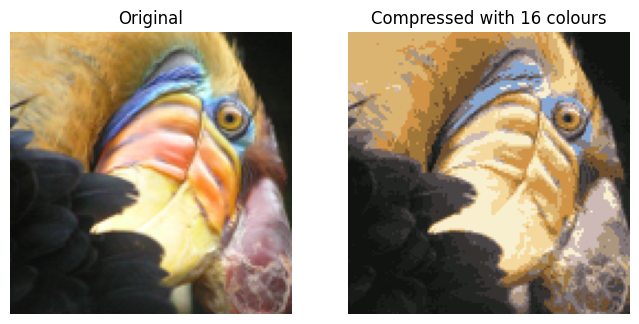

In [28]:
# Display original image
fig, ax = plt.subplots(1,2, figsize=(8,8))
plt.axis('off')

ax[0].imshow(original_img*255)
ax[0].set_title('Original')
ax[0].set_axis_off()


# Display compressed image
ax[1].imshow(X_recovered*255)
ax[1].set_title('Compressed with %d colours'%K)
ax[1].set_axis_off()